# Two Steps MultiFidelity Neural Network

In [ ]:
# BUON RISULTATO, POCO GENERALE

In [26]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data, normalization
from time import perf_counter
import pandas
import pickle
import os
import keras

In [27]:
# reproducibility
seed = 42
np.random.seed(seed)

keras.utils.set_random_seed(seed)

import tensorflow as tf
tf.random.set_seed(seed)

## Data Preparation

In [28]:
# import of the discretization and diffusion values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [29]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

reaction_HF_test = normalization(reaction_HF_test)
# randomization
permutation = np.random.permutation(len(reaction_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation][0:n_HF]


U_HF_test = U_HF_test[:, -1, 44,44]
U_HF_test=normalization(U_HF_test)
# randomization
U_HF = U_HF_test[permutation][0:n_HF]


In [30]:
U_LF_list = []
U_HF_list = []

NepoLF = 5000  # number of epochs for first NN: NN_LF
NepoHF = 3000  # number of epochs for second NN: NN_HF
Nlf = 30

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE


In [36]:
print(reaction_LF_test.shape)

(50, 1)


## Neural Network
Cycle on the Discretization and the value of the diffusion 

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.13945763911375186
R^2: -0.118604644611642
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.749251200002618

HF Model:
Test MSE: 0.11587779267184345
R^2: -0.023666381485986543
2/2 [==============================] - 0s 0s/step


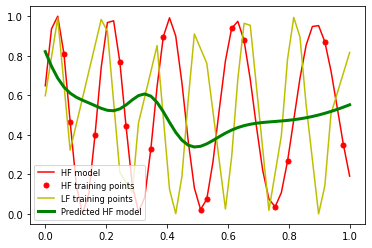

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.11937591919967291
R^2: 0.04047568020816872
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.723638999974355

HF Model:
Test MSE: 0.11159471609145619
R^2: 0.014170389508510906
2/2 [==============================] - 0s 3ms/step


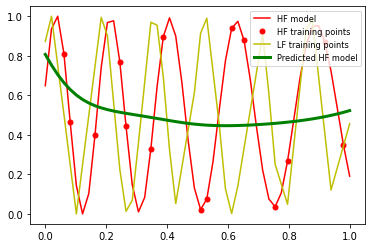

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.12870295926772102
R^2: -0.008851375890778668
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.780445100041106

HF Model:
Test MSE: 0.11315266645952146
R^2: 0.00040742959151851554
2/2 [==============================] - 0s 0s/step


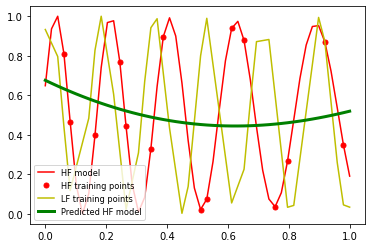

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.12319348829592433
R^2: -0.013993135700221426
2/2 [==============================] - 0s 3ms/step
Elapsed time:  17.631639400031418

HF Model:
Test MSE: 0.11301268962872406
R^2: 0.0016439872836384595
2/2 [==============================] - 0s 4ms/step


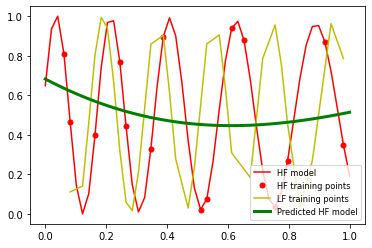

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 9ms/step

LF Model:
Test MSE: 0.12216734610203069
R^2: 0.019763069724188398
2/2 [==============================] - 0s 14ms/step
Elapsed time:  19.022309999912977

HF Model:
Test MSE: 0.11327347404090621
R^2: -0.0006597866268849284
2/2 [==============================] - 0s 3ms/step


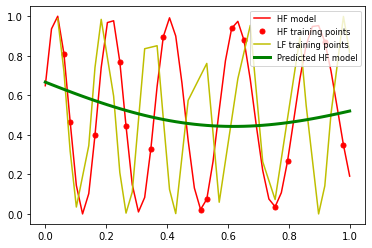

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.11652987203444344
R^2: -0.0288935248601343
2/2 [==============================] - 0s 16ms/step
Elapsed time:  17.68084569997154

HF Model:
Test MSE: 0.11305447810844989
R^2: 0.0012748271465458094
2/2 [==============================] - 0s 18ms/step


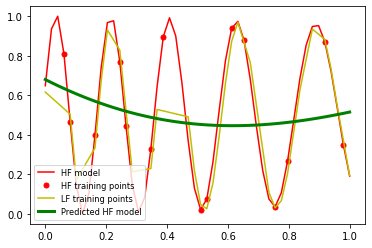

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.1322735609204499
R^2: -0.12499827541739505
2/2 [==============================] - 0s 16ms/step
Elapsed time:  18.003029100014828

HF Model:
Test MSE: 0.11304814446003719
R^2: 0.0013307787038091545
2/2 [==============================] - 0s 3ms/step


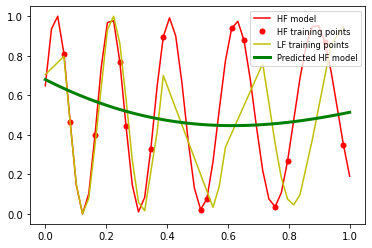

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.12000841259436268
R^2: -0.014903469498756428
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.581077799899504

HF Model:
Test MSE: 0.1124897528199544
R^2: 0.0062636199020732475
2/2 [==============================] - 0s 0s/step


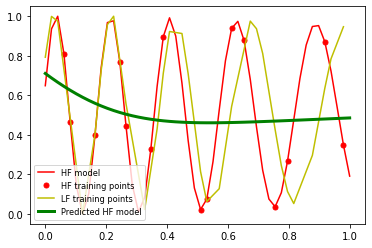

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.14164519479020657
R^2: -0.1369619648581426
2/2 [==============================] - 0s 3ms/step
Elapsed time:  17.615544600063004

HF Model:
Test MSE: 0.11180568891452212
R^2: 0.01230665201921144
2/2 [==============================] - 0s 0s/step


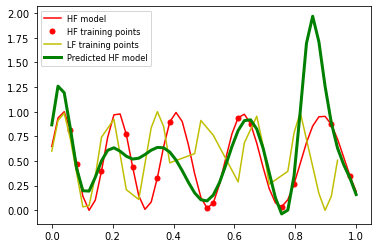

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.008408414007112083
R^2: 0.9260874288153012
2/2 [==============================] - 0s 0s/step
Elapsed time:  17.541024600039236

HF Model:
Test MSE: 0.03100501881633269
R^2: 0.7261011390724199
2/2 [==============================] - 0s 0s/step


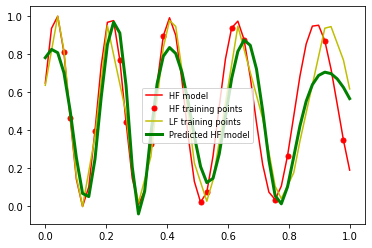

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.11543939149005102
R^2: 0.01994096278725299
2/2 [==============================] - 0s 1ms/step
Elapsed time:  17.642679500044324

HF Model:
Test MSE: 0.11246261076883143
R^2: 0.0065033932410237805
2/2 [==============================] - 0s 0s/step


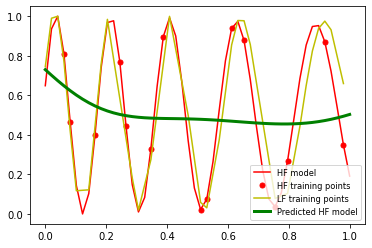

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.11728109735920833
R^2: -0.013184345683793008
2/2 [==============================] - 0s 4ms/step
Elapsed time:  17.577821800019592

HF Model:
Test MSE: 0.11294384742181805
R^2: 0.0022521405044765297
2/2 [==============================] - 0s 3ms/step


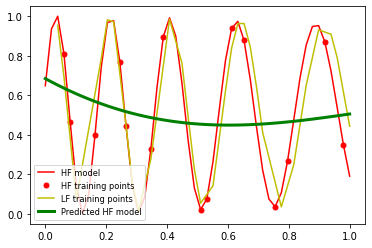

    Discretization  diffusion       R2
0             10.0        0.0 -0.02367
1             10.0        5.0  0.01417
2             10.0       75.0  0.00041
3             10.0        1.0  0.00164
4             28.0        0.0 -0.00066
5             28.0        5.0  0.00127
6             28.0       75.0  0.00133
7             28.0        1.0  0.00626
8             46.0        0.0  0.01231
9             46.0        5.0  0.72610
10            46.0       75.0  0.00650
11            46.0        1.0  0.00225
    Discretization  diffusion      MSE
0             10.0        0.0  0.11588
1             10.0        5.0  0.11159
2             10.0       75.0  0.11315
3             10.0        1.0  0.11301
4             28.0        0.0  0.11327
5             28.0        5.0  0.11305
6             28.0       75.0  0.11305
7             28.0        1.0  0.11249
8             46.0        0.0  0.11181
9             46.0        5.0  0.03101
10            46.0       75.0  0.11246
11            46.0       

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:196: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df=r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:198: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df=r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:200: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df=mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_8784\4169971148.py:202: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df=mse_HF_df.append(new,

In [31]:
for m in range(len(Discretizations)):
    for d in range(len(diffusion)):
        
        ### IMPORT LF DATASETs
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        
        reaction_LF_test = normalization(reaction_LF_test)
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]        
        U_LF_test = normalization(U_LF_test)
        
        # randomization
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []

        r2_HF_list = []
        r2_LF_list = []
        
        ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        } 
        
        # reproducibilty porpuse 
        learning_rate = bestLF_params["lr"]
        optimizer_type = bestLF_params["opt"]

        # Fissa i parametri di ottimizzazione
        if optimizer_type == "Adam":
            optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Nadam":
            optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Adamax":
            optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        else:
            raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
        #

        
        modelLF = getModel(bestLF_params, "LF")  # ann_functions
        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
       
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)

        U_LF_list.append(ULF)
        print("\nLF Model:")
        
        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")
        
        start = perf_counter()
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_HF

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_HF

        name = "2step"
        K.clear_session()
        # best parameters obtained by HPO:

        best_params = {
            "kernel_init": "uniform",
            "l2weight": 0.0002588943618918075,
            "lr": 0.008365144388542751,
            "nodes": 6.0,
            "opt": "Adam",
        }
        
         # reproducibilty porpuse 
        learning_rate = best_params["lr"]
        optimizer_type = best_params["opt"]

        # Fissa i parametri di ottimizzazione
        if optimizer_type == "Adam":
            optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Nadam":
            optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        elif optimizer_type == "Adamax":
            optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
        else:
            raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
        #
        
        
        
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            verbose=0,
            validation_freq=20,
        )

        UHF = finalModel.predict(reaction_test_in)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)
        print("\nHF Model:")

        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")
        
        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "r-", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "ro",
        markersize=5,
        label="HF training points",
        )
        
        
        order=np.argsort(reaction_LF[:,0])
        
        plt.plot(
        reaction_LF[order,0],
        U_train_LF[order],
        "y-",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_in),
        "g-",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()

        #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
        #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
        #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
        #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
        
        
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
        r2_LF_df=r2_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
        r2_HF_df=r2_HF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
        mse_LF_df=mse_LF_df.append(new, ignore_index=True)
        new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
        mse_HF_df=mse_HF_df.append(new, ignore_index=True)
        
        if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
            save_model(finalModel,"finalModel2NN.h5")
        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))



In [32]:
order=np.argsort(reaction_LF[:,0])

print(order)

[16 26 24 19  3 22  2  1 14  7 17 12 18 28 10 15 20  5 11 21  6  9 23  4
 25  8 27 29  0 13]


In [33]:
print( reaction_LF[order][:,0,0])

IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

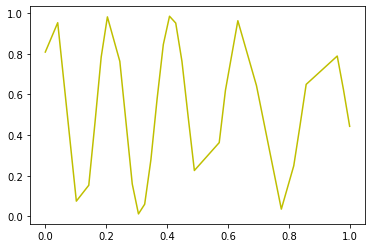

In [ ]:
order=np.argsort(reaction_LF[:,0])
        
plt.plot(
        reaction_LF[order,0],
        U_train_LF[order],
        "y-",
        markersize=5,
        label="LF training points",
        )

## Save the output

In [ ]:
os.makedirs("MF_LF_30_5000_HF_15_3000_2NN2")

r2_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN2/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN2/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN2/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_30_5000_HF_15_3000_2NN2/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_30_5000_HF_15_3000_2NN2/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_30_5000_HF_15_3000_2NN2/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_30_5000_HF_15_3000_2NN2'